In [ ]:
import os, sys
sys.path.append('../')

# 15 客群分析 & 策略分析 EDA 演示

本 Notebook 演示 `hscredit.core.eda` 中新增的两大模块：

| 模块 | 函数 | 用途 |
|------|------|------|
| `population` | `population_profile` | 客群画像（均值/分位数/坏率） |
| `population` | `population_shift_analysis` | 两数据集客群偏移对比 |
| `population` | `segment_drift_analysis` | 分客群×时间三维偏移矩阵 |
| `population` | `feature_cross_segment_effectiveness` | 特征在各客群的 IV/KS/AUC 矩阵 |
| `strategy` | `approval_badrate_tradeoff` | 通过率 vs 坏率权衡曲线 |
| `strategy` | `score_strategy_simulation` | 多阈值策略仿真 |
| `strategy` | `vintage_performance_summary` | Vintage 账龄绩效宽表 |
| `strategy` | `roll_rate_matrix` | DPD 滚动率矩阵 |
| `strategy` | `label_leakage_check` | 标签泄露检测 |
| `strategy` | `multi_label_correlation` | 多标签相关性矩阵 |
| `stability` | `feature_drift_report` | 批量特征偏移报告 |
| `stability` | `score_drift_report` | 评分分布偏移报告 |

**数据来源**: German Credit (内置，1000 条) + 合成扩展字段（channel, score, vintage, mob, dpd）

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

import hscredit as hs
import hscredit.core.eda as eda
from hscredit.utils.datasets import germancredit

# ── 加载基础数据 ──────────────────────────────────────────────
base = germancredit()
print('原始字段:', list(base.columns))

# ── 目标变量 ──────────────────────────────────────────────────
base = base.rename(columns={'class': 'target'})

# ── 简化列名，便于演示 ─────────────────────────────────────────
base = base.rename(columns={
    'duration_in_month': 'duration',
    'age_in_years': 'age',
    'installment_rate_in_percentage_of_disposable_income': 'installment_rate',
})

# ── 构造演示字段 ──────────────────────────────────────────────
rng = np.random.default_rng(42)
n = len(base)

# 评分（与 target 负相关）
base['score'] = (
    700
    - base['target'] * 150
    + rng.normal(0, 40, n)
).clip(300, 850).round(1)

# 渠道（客群分组）
base['channel'] = rng.choice(['线上', '线下', '中介'], n, p=[0.5, 0.3, 0.2])

# 放款月份（12 个月，模拟时间维度）
months = pd.date_range('2023-01', periods=12, freq='MS')
base['loan_month'] = rng.choice([str(m.to_period('M')) for m in months], n)

# 账龄 MOB（1-24 个月）
base['mob'] = rng.integers(1, 25, n)

# 逾期天数 t0 / t1（DPD）
base['dpd_t0'] = rng.choice([0, 0, 0, 1, 7, 15, 30, 60, 90], n)
base['dpd_t1'] = (base['dpd_t0'] * rng.uniform(0.5, 2.0, n)).clip(0, 120).astype(int)

# 贷款金额
base['loan_amount'] = base['credit_amount']

# 分训练集 / 生产集（后 30% 模拟分布漂移）
split = int(n * 0.7)
df_train = base.iloc[:split].copy().reset_index(drop=True)
df_prod  = base.iloc[split:].copy().reset_index(drop=True)
# 给生产集 age 注入偏移
df_prod['age'] = df_prod['age'] + rng.normal(3, 2, len(df_prod))

num_features = ['duration', 'credit_amount', 'installment_rate', 'age', 'score']

print(f'训练集: {len(df_train):,}  生产集: {len(df_prod):,}')
print(f'坏率 - 训练: {df_train["target"].mean():.2%}  生产: {df_prod["target"].mean():.2%}')
print('数值特征:', num_features)

原始字段: ['status_of_existing_checking_account', 'duration_in_month', 'credit_history', 'purpose', 'credit_amount', 'savings_account_and_bonds', 'present_employment_since', 'installment_rate_in_percentage_of_disposable_income', 'personal_status_and_sex', 'other_debtors_or_guarantors', 'present_residence_since', 'property', 'age_in_years', 'other_installment_plans', 'housing', 'number_of_existing_credits_at_this_bank', 'job', 'number_of_people_being_liable_to_provide_maintenance_for', 'telephone', 'foreign_worker', 'class']
训练集: 700  生产集: 300
坏率 - 训练: 29.57%  生产: 31.00%
数值特征: ['duration', 'credit_amount', 'installment_rate', 'age', 'score']


---
## Part 1 — 客群画像与偏移分析 (`population` 模块)

### 1.1 `population_profile` — 客群画像

In [3]:
# ── 全量画像（不分组）──────────────────────────────────────────
profile_all = eda.population_profile(
    base, features=num_features, target='target'
)
print('全量客群画像:')
display(profile_all)

全量客群画像:


,特征,分组,样本数,缺失率(%),均值,标准差,p25,p50,p75,坏率(%)
0,duration,全量,1000,0.0,20.9030,12.0588,12.000,18.0,24.00,30.0
1,credit_amount,全量,1000,0.0,3271.2580,2822.7369,1365.500,2319.5,3972.25,30.0
2,installment_rate,全量,1000,0.0,2.9730,1.1187,2.000,3.0,4.00,30.0
3,age,全量,1000,0.0,35.5460,11.3755,27.000,33.0,42.00,30.0
4,score,全量,1000,0.0,653.8448,78.8144,587.375,677.8,712.60,30.0



按渠道分组画像:


,特征,分组,样本数,缺失率(%),均值,标准差,p25,p50,p75,坏率(%)
0,duration,中介,213,0.0,21.3427,12.0780,12.000,18.00,24.00,30.9859
1,credit_amount,中介,213,0.0,3467.2864,3139.1450,1355.000,2384.00,4139.00,30.9859
2,score,中介,213,0.0,649.0427,81.4647,589.500,673.20,709.40,30.9859
3,duration,线上,512,0.0,21.1328,12.3872,12.000,18.00,24.00,32.0312
4,credit_amount,线上,512,0.0,3108.1719,2614.2911,1320.500,2218.50,3879.25,32.0312
5,score,线上,512,0.0,650.0467,80.0341,575.725,673.45,711.10,32.0312
6,duration,线下,275,0.0,20.1345,11.4152,12.000,18.00,24.00,25.4545
7,credit_amount,线下,275,0.0,3423.0618,2928.7152,1420.000,2503.00,4051.50,25.4545
8,score,线下,275,0.0,664.6356,73.5209,622.850,687.00,715.25,25.4545


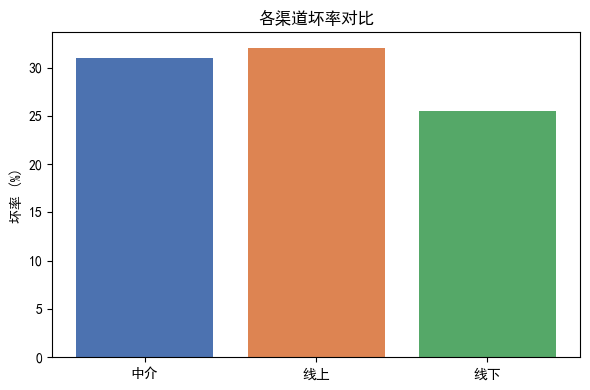

In [4]:
# ── 按渠道分组 ─────────────────────────────────────────────────
profile_seg = eda.population_profile(
    base,
    features=['duration', 'credit_amount', 'score'],
    segment_col='channel',
    target='target',
)
print('\n按渠道分组画像:')
display(profile_seg)

# 可视化坏率对比
pivot = profile_seg[profile_seg['特征'] == 'score'].copy()
if '坏率(%)' in pivot.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(pivot['分组'], pivot['坏率(%)'], color=['#4C72B0','#DD8452','#55A868'])
    ax.set_title('各渠道坏率对比')
    ax.set_ylabel('坏率 (%)')
    plt.tight_layout(); plt.show()

### 1.2 `population_shift_analysis` — 客群偏移分析

客群偏移摘要（训练集 vs 生产集）:


,特征名,基准样本数,目标样本数,PSI,偏移等级,基准均值,目标均值,均值变化(%),基准缺失率(%),目标缺失率(%),缺失率变化(%),建议,基准坏率(%),目标坏率(%)
0,age,700,300,0.2606,显著偏移,35.3229,39.0458,10.54,0.0,0.0,0.0,强烈建议排查原因，可能影响模型效果,29.5714,31.0
1,duration,700,300,0.0493,稳定,20.6529,21.4867,4.04,0.0,0.0,0.0,无需关注,29.5714,31.0
2,score,700,300,0.0332,稳定,654.1064,653.2343,-0.13,0.0,0.0,0.0,无需关注,29.5714,31.0
3,credit_amount,700,300,0.0206,稳定,3182.3314,3478.7533,9.31,0.0,0.0,0.0,无需关注,29.5714,31.0
4,installment_rate,700,300,0.0004,稳定,2.9729,2.9733,0.02,0.0,0.0,0.0,无需关注,29.5714,31.0


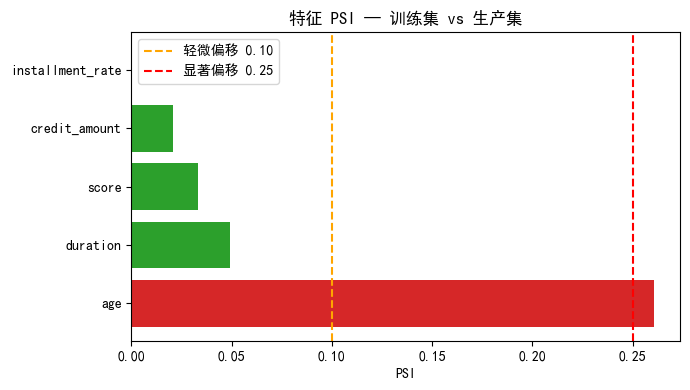

In [5]:
drift = eda.population_shift_analysis(
    df_train, df_prod,
    features=num_features,
    target='target',
    psi_n_bins=10,
)
print('客群偏移摘要（训练集 vs 生产集）:')
display(drift)

# 可视化 PSI
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d62728' if r == '显著偏移' else '#ff7f0e' if r == '轻微偏移' else '#2ca02c'
          for r in drift['偏移等级']]
ax.barh(drift['特征名'], drift['PSI'], color=colors)
ax.axvline(0.1, color='orange', linestyle='--', label='轻微偏移 0.10')
ax.axvline(0.25, color='red', linestyle='--', label='显著偏移 0.25')
ax.set_xlabel('PSI')
ax.set_title('特征 PSI — 训练集 vs 生产集')
ax.legend()
plt.tight_layout(); plt.show()

### 1.3 `segment_drift_analysis` — 分客群×时间偏移

三维偏移矩阵: (66, 8)


,特征名,客群,时间,基准期,PSI,偏移等级,基准坏率(%),当期坏率(%)
0,duration,中介,2023-02,2023-01,0.0348,非常稳定,23.08,18.18
1,duration,中介,2023-03,2023-01,0.7436,不稳定,23.08,53.85
2,duration,中介,2023-04,2023-01,0.7638,不稳定,23.08,25.00
3,duration,中介,2023-05,2023-01,2.1191,不稳定,23.08,40.00
4,duration,中介,2023-06,2023-01,2.9096,不稳定,23.08,52.94
5,duration,中介,2023-07,2023-01,0.6575,不稳定,23.08,29.41
6,duration,中介,2023-08,2023-01,0.6765,不稳定,23.08,11.76
7,duration,中介,2023-09,2023-01,1.9421,不稳定,23.08,27.78
8,duration,中介,2023-10,2023-01,9.5601,不稳定,23.08,41.67
9,duration,中介,2023-11,2023-01,4.0070,不稳定,23.08,30.00


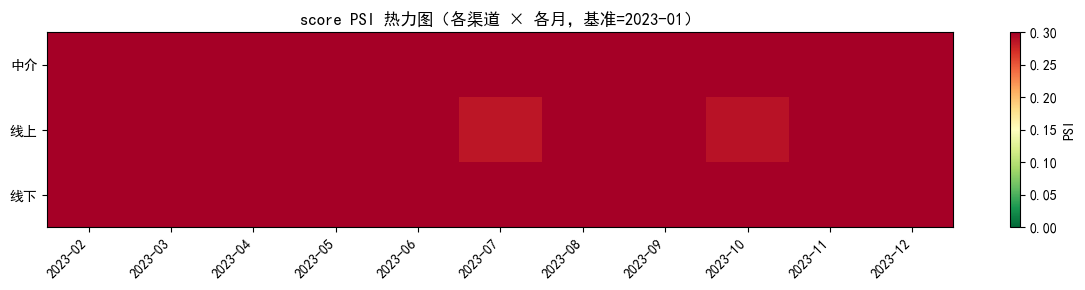

In [6]:
seg_drift = eda.segment_drift_analysis(
    base,
    date_col='loan_month',
    segment_col='channel',
    features=['score', 'duration'],
    target='target',
    base_period='2023-01',
    freq='M',
)
print(f'三维偏移矩阵: {seg_drift.shape}')
display(seg_drift.head(20))

# Heatmap：score 特征在各渠道各月的 PSI
score_pivot = seg_drift[seg_drift['特征名'] == 'score'].pivot(
    index='客群', columns='时间', values='PSI'
)
if not score_pivot.empty:
    fig, ax = plt.subplots(figsize=(12, 3))
    im = ax.imshow(score_pivot.values.astype(float), aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.3)
    ax.set_xticks(range(len(score_pivot.columns)))
    ax.set_xticklabels(score_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(score_pivot.index)))
    ax.set_yticklabels(score_pivot.index)
    ax.set_title('score PSI 热力图（各渠道 × 各月，基准=2023-01）')
    plt.colorbar(im, ax=ax, label='PSI')
    plt.tight_layout(); plt.show()

### 1.4 `feature_cross_segment_effectiveness` — 特征分渠道有效性矩阵

In [7]:
# IV 矩阵
iv_matrix = eda.feature_cross_segment_effectiveness(
    base, features=num_features, target='target',
    segment_col='channel', metric='iv',
)
print('特征 IV 矩阵（各渠道）:')
display(iv_matrix)

# AUC 矩阵
auc_matrix = eda.feature_cross_segment_effectiveness(
    base, features=num_features, target='target',
    segment_col='channel', metric='auc',
)
print('\n特征 AUC 矩阵（各渠道）:')
display(auc_matrix)

特征 IV 矩阵（各渠道）:


,特征名,全量,中介,线上,线下
0,score,41.0312,38.1285,46.8404,41.0273
1,duration,0.2669,3.7110,0.2563,0.4216
2,credit_amount,0.1218,0.2797,0.0491,0.3612
3,age,0.0878,0.1137,0.1186,0.0603
4,installment_rate,0.0198,0.0870,0.0110,0.0078



特征 AUC 矩阵（各渠道）:


,特征名,全量,中介,线上,线下
0,duration,0.6286,0.6912,0.6169,0.5969
1,credit_amount,0.5549,0.5413,0.5440,0.5985
2,installment_rate,0.5434,0.6059,0.5248,0.5288
3,age,0.4294,0.4358,0.4087,0.4687
4,score,0.0040,0.0067,0.0034,0.0042


---
## Part 2 — 策略分析 (`strategy` 模块)

### 2.1 `approval_badrate_tradeoff` — 通过率 vs 坏率权衡

权衡曲线点数: 100


,评分阈值,通过率(%),拒绝率(%),通过人数,拒绝人数,通过人群坏率(%),拒绝人群坏率(%),通过人群坏样本数,拒绝人群坏样本数
0,782.4762,1.0,99.0,10,990,0.0,30.3030,0,300
1,772.8218,2.0,98.0,20,980,0.0,30.6122,0,300
2,766.4248,3.0,97.0,30,970,0.0,30.9278,0,300
3,760.8356,4.0,96.0,40,960,0.0,31.2500,0,300
4,758.1089,5.0,95.0,50,950,0.0,31.5789,0,300
5,753.8267,6.0,94.0,60,940,0.0,31.9149,0,300
6,749.8762,7.0,93.0,70,930,0.0,32.2581,0,300
7,746.1614,8.0,92.0,80,920,0.0,32.6087,0,300
8,742.5960,9.0,91.0,90,910,0.0,32.9670,0,300
9,738.2069,9.9,90.1,99,901,0.0,33.2963,0,300


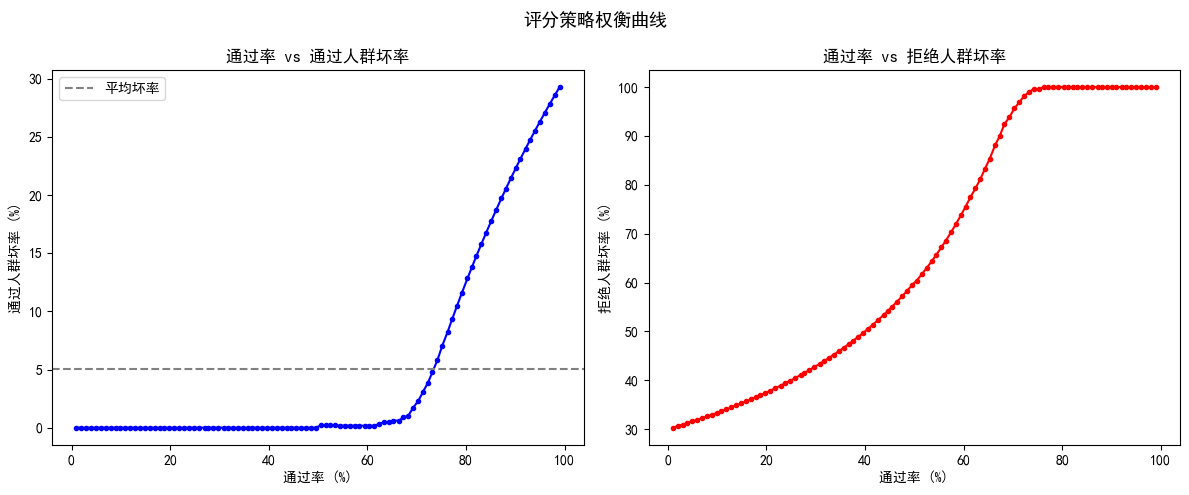


坏率约束 ≤25% 时最优阈值: 516.7
  通过率: 93.0%   通过坏率: 24.73%


In [8]:
tradeoff = eda.approval_badrate_tradeoff(
    y_true=base['target'],
    score=base['score'],
    n_points=100,
    score_low_risk='high',
)
print(f'权衡曲线点数: {len(tradeoff)}')
display(tradeoff.head(10))

# 可视化权衡曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(tradeoff['通过率(%)'], tradeoff['通过人群坏率(%)'], 'b-o', markersize=3)
ax.axhline(y=tradeoff['通过人群坏率(%)'].mean(), color='gray', linestyle='--', label='平均坏率')
ax.set_xlabel('通过率 (%)')
ax.set_ylabel('通过人群坏率 (%)')
ax.set_title('通过率 vs 通过人群坏率')
ax.legend()

ax2 = axes[1]
ax2.plot(tradeoff['通过率(%)'], tradeoff['拒绝人群坏率(%)'], 'r-o', markersize=3)
ax2.set_xlabel('通过率 (%)')
ax2.set_ylabel('拒绝人群坏率 (%)')
ax2.set_title('通过率 vs 拒绝人群坏率')

plt.suptitle('评分策略权衡曲线', fontsize=13)
plt.tight_layout(); plt.show()

# 找到坏率 ≤ 25% 时通过率最高的阈值
best = tradeoff[tradeoff['通过人群坏率(%)'] <= 25].sort_values('通过率(%)', ascending=False).head(1)
if not best.empty:
    row = best.iloc[0]
    print(f'\n坏率约束 ≤25% 时最优阈值: {row["评分阈值"]:.1f}')
    print(f'  通过率: {row["通过率(%)"]:.1f}%   通过坏率: {row["通过人群坏率(%)"]:.2f}%')

### 2.2 `score_strategy_simulation` — 多阈值策略仿真

策略仿真结果：


,评分阈值,通过量(笔),通过率(%),通过人群坏率(%),捕获坏样本数,拒绝量(笔),拒绝率(%),拒绝坏样本数,坏样本拦截率(%),通过金额,通过人群坏账金额,"坏账率(金额,%)"
0,550,855,85.5,18.1287,155,145,14.5,145,48.33,2749412.0,659592.0,23.9903
1,580,769,76.9,8.9727,69,231,23.1,231,77.00,2387373.0,297553.0,12.4636
2,610,710,71.0,2.9577,21,290,29.0,279,93.00,2139692.0,98306.0,4.5944
3,640,657,65.7,0.6088,4,343,34.3,296,98.67,1966109.0,26960.0,1.3712
4,670,538,53.8,0.1859,1,462,46.2,299,99.67,1590716.0,6761.0,0.4250


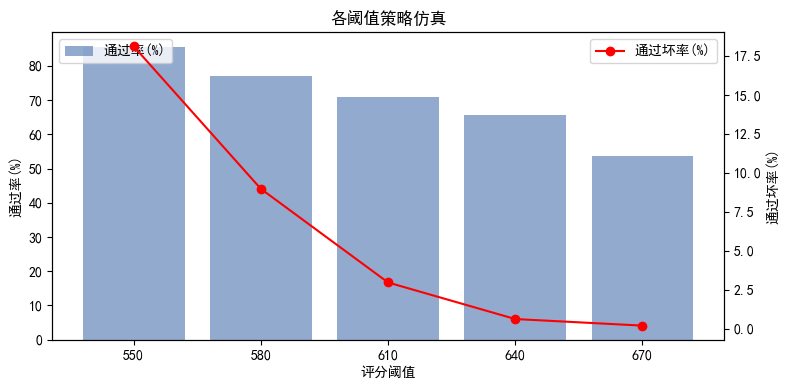

In [9]:
# 定义若干候选阈值
thresholds = [550, 580, 610, 640, 670]

sim = eda.score_strategy_simulation(
    base,
    score_col='score',
    target='target',
    thresholds=thresholds,
    amount_col='loan_amount',
    score_low_risk='high',
)
print('策略仿真结果：')
display(sim)

# 可视化
fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()
ax.bar([str(t) for t in sim['评分阈值']], sim['通过率(%)'], alpha=0.6, label='通过率(%)', color='#4C72B0')
ax2.plot([str(t) for t in sim['评分阈值']], sim['通过人群坏率(%)'], 'r-o', label='通过坏率(%)')
ax.set_xlabel('评分阈值')
ax.set_ylabel('通过率(%)')
ax2.set_ylabel('通过坏率(%)')
ax.set_title('各阈值策略仿真')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

### 2.3 `vintage_performance_summary` — Vintage 账龄绩效

Vintage 账龄绩效宽表:


,Vintage,MOB3_样本数,MOB3_坏率(%),"MOB3_坏账率(金额,%)",MOB6_样本数,MOB6_坏率(%),"MOB6_坏账率(金额,%)",MOB9_样本数,MOB9_坏率(%),"MOB9_坏账率(金额,%)",MOB12_样本数,MOB12_坏率(%),"MOB12_坏账率(金额,%)",MOB18_样本数,MOB18_坏率(%),"MOB18_坏账率(金额,%)",MOB24_样本数,MOB24_坏率(%),"MOB24_坏账率(金额,%)"
0,2023-01,8,12.5000,11.6388,23,30.4348,36.4800,37,24.3243,37.2026,48,22.9167,29.4797,71,25.3521,32.3153,94,23.4043,28.4255
1,2023-02,7,0.0000,0.0000,19,15.7895,16.0140,28,21.4286,26.3043,37,21.6216,22.5835,63,20.6349,16.9375,83,22.8916,20.6149
2,2023-03,8,37.5000,53.4474,23,39.1304,48.7410,28,39.2857,49.6761,36,36.1111,46.9155,48,37.5000,43.3720,68,38.2353,43.3516
3,2023-04,11,36.3636,52.0866,28,46.4286,58.5161,37,45.9459,58.9904,52,36.5385,46.6092,77,33.7662,43.1562,100,32.0000,39.9547
4,2023-05,11,27.2727,21.2283,21,28.5714,44.2572,33,42.4242,57.5866,49,40.8163,53.6357,72,37.5000,48.5948,87,34.4828,44.0466
5,2023-06,9,44.4444,59.6760,18,50.0000,68.6115,28,42.8571,58.5843,37,40.5405,60.4975,63,42.8571,49.4061,76,42.1053,49.4443
6,2023-07,7,14.2857,41.0796,13,23.0769,51.5598,29,24.1379,33.6275,41,24.3902,35.8085,63,23.8095,35.3952,81,22.2222,31.3799
7,2023-08,10,20.0000,43.6069,22,31.8182,42.1752,31,29.0323,38.5421,40,25.0000,30.6350,55,21.8182,26.4256,71,21.1268,24.9463
8,2023-09,10,50.0000,61.5837,17,35.2941,55.6620,27,33.3333,53.5107,38,34.2105,48.2338,57,35.0877,43.1838,77,31.1688,39.1279
9,2023-10,11,27.2727,38.4463,21,33.3333,43.4954,25,36.0000,43.6345,38,36.8421,43.0047,62,37.0968,48.5600,83,34.9398,45.8041


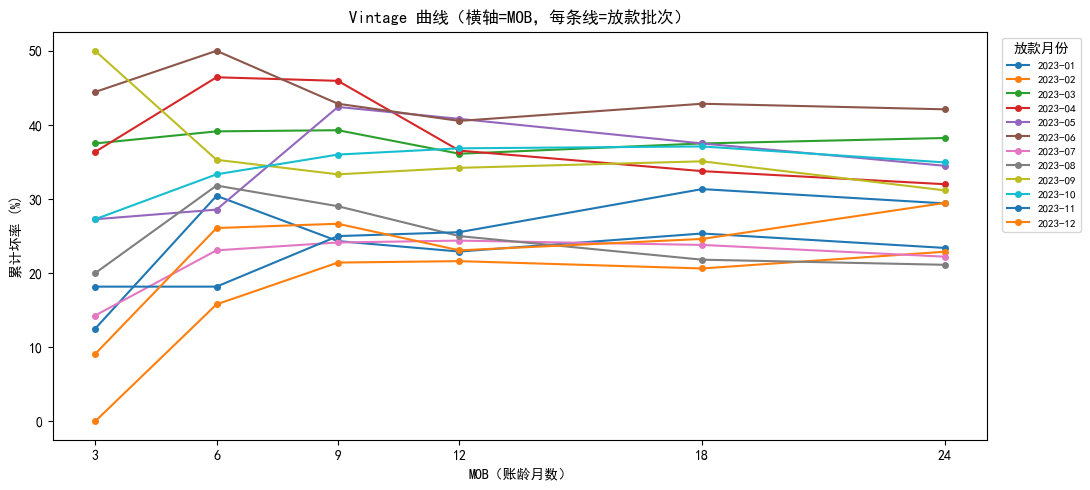

In [10]:
import re

vintage_summary = eda.vintage_performance_summary(
    base,
    vintage_col='loan_month',
    mob_col='mob',
    target_col='target',
    mob_points=[3, 6, 9, 12, 18, 24],
    amount_col='loan_amount',
)
print('Vintage 账龄绩效宽表:')
display(vintage_summary)

# ── 标准 Vintage 曲线：横轴=MOB，纵轴=坏率，每条线=一个放款批次 ──
mob_cols = [c for c in vintage_summary.columns if re.match(r'MOB\d+_坏率\(%\)', c)]
if mob_cols:
    mob_nums = [int(re.search(r'MOB(\d+)', c).group(1)) for c in mob_cols]

    fig, ax = plt.subplots(figsize=(11, 5))
    for _, row in vintage_summary.iterrows():
        y_vals = [row[c] for c in mob_cols]
        ax.plot(mob_nums, y_vals, marker='o', markersize=4, label=str(row['Vintage']))

    ax.set_xlabel('MOB（账龄月数）')
    ax.set_ylabel('累计坏率 (%)')
    ax.set_title('Vintage 曲线（横轴=MOB，每条线=放款批次）')
    ax.set_xticks(mob_nums)
    ax.legend(title='放款月份', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()


### 2.4 `roll_rate_matrix` — DPD 滚动率矩阵

In [11]:
roll_result = eda.roll_rate_matrix(
    base,
    dpd_t0='dpd_t0',
    dpd_t1='dpd_t1',
    bins=[0, 1, 7, 15, 30, 60, 90, 120, float('inf')],
    mob_t0=12,
    mob_t1=18,
    amount_col='loan_amount',
)

print('── 元信息（订单 & 金额两口径整体迁移汇总） ──')
display(roll_result['元信息'])

print('\n── 计数矩阵（多层列头，含变好/保持/变坏/合计） ──')
display(roll_result['计数矩阵'])

print('\n── 订单比例矩阵（行归一化，原始小数） ──')
display(roll_result['订单比例矩阵'])

if '金额矩阵' in roll_result:
    print('\n── 金额矩阵（多层列头，含变好/保持/变坏金额） ──')
    display(roll_result['金额矩阵'])

    print('\n── 金额比例矩阵（行归一化，原始小数） ──')
    display(roll_result['金额比例矩阵'])


── 元信息（订单 & 金额两口径整体迁移汇总） ──


,口径,观察点,表现点,观察期DPD列,表现期DPD列,总量,变好量,保持量,变坏量,变好率,保持率,变坏率
0,订单,MOB12,MOB18,dpd_t0,dpd_t1,1000.0,217.0,709.0,74.0,0.2170,0.7090,0.0740
1,金额,MOB12,MOB18,dpd_t0,dpd_t1,3271258.0,698573.0,2316281.0,256404.0,0.2135,0.7081,0.0784



── 计数矩阵（多层列头，含变好/保持/变坏/合计） ──


MOB18                                                  汇总        \
                 D0 D1-7 D8-15 D16-30 D31-60 D61-90 D91-120 D120+ 变好（笔） 保持（笔）   
观察点   DPD状态                                                                     
MOB12 D0        370    0     0      0      0      0       0     0     0   370   
      D1-7       28   60     0      0      0      0       0     0    28    60   
      D8-15       0   42    74      0      0      0       0     0    42    74   
      D16-30      0    0    39     68      0      0       0     0    39    68   
      D31-60      0    0     0     34     73      0       0     0    34    73   
      D61-90      0    0     0      0     37     38      35     0    37    38   
      D91-120     0    0     0      0     11     26      26    39    37    26   
      D120+       0    0     0      0      0      0       0     0     0     0   

                           
              变坏（笔） 合计（笔）  
观察点   DPD状态                
MOB12 D0          0   370  
      D1-7        0    88  
      D8-15       0   116  
      D16-30      0   107  
      D31-60      0   107  
      D61-90     35   110  
      D91-120    39   102  
      D120+       0     0


── 订单比例矩阵（行归一化，原始小数） ──


MOB18                                                    \
                     D0      D1-7     D8-15    D16-30    D31-60    D61-90   
观察点   DPD状态                                                                 
MOB12 D0       1.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      D1-7     0.318182  0.681818  0.000000  0.000000  0.000000  0.000000   
      D8-15    0.000000  0.362069  0.637931  0.000000  0.000000  0.000000   
      D16-30   0.000000  0.000000  0.364486  0.635514  0.000000  0.000000   
      D31-60   0.000000  0.000000  0.000000  0.317757  0.682243  0.000000   
      D61-90   0.000000  0.000000  0.000000  0.000000  0.336364  0.345455   
      D91-120  0.000000  0.000000  0.000000  0.000000  0.107843  0.254902   
      D120+    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

                                         汇总                      
                D91-120     D120+        变好        保持        变坏  
观察点   DPD状态                                                      
MOB12 D0       0.000000  0.000000  0.000000  1.000000  0.000000  
      D1-7     0.000000  0.000000  0.318182  0.681818  0.000000  
      D8-15    0.000000  0.000000  0.362069  0.637931  0.000000  
      D16-30   0.000000  0.000000  0.364486  0.635514  0.000000  
      D31-60   0.000000  0.000000  0.317757  0.682243  0.000000  
      D61-90   0.318182  0.000000  0.336364  0.345455  0.318182  
      D91-120  0.254902  0.382353  0.362745  0.254902  0.382353  
      D120+    0.000000  0.000000  0.000000  0.000000  0.000000


── 金额矩阵（多层列头，含变好/保持/变坏金额） ──


MOB18                                                  \
                    D0    D1-7   D8-15  D16-30  D31-60  D61-90 D91-120   
观察点   DPD状态                                                              
MOB12 D0       1121849       0       0       0       0       0       0   
      D1-7       88309  230890       0       0       0       0       0   
      D8-15          0  128261  241373       0       0       0       0   
      D16-30         0       0  129100  241998       0       0       0   
      D31-60         0       0       0  106021  233925       0       0   
      D61-90         0       0       0       0  123861  169236  128696   
      D91-120        0       0       0       0   26263   96758   77010   
      D120+          0       0       0       0       0       0       0   

                           汇总                            
                D120+  变好（金额）   保持（金额）  变坏（金额）   合计（金额）  
观察点   DPD状态                                              
MOB12 D0            0       0  1121849       0  1121849  
      D1-7          0   88309   230890       0   319199  
      D8-15         0  128261   241373       0   369634  
      D16-30        0  129100   241998       0   371098  
      D31-60        0  106021   233925       0   339946  
      D61-90        0  123861   169236  128696   421793  
      D91-120  127708  123021    77010  127708   327739  
      D120+         0       0        0       0        0


── 金额比例矩阵（行归一化，原始小数） ──


MOB18                                                    \
                     D0      D1-7     D8-15    D16-30    D31-60    D61-90   
观察点   DPD状态                                                                 
MOB12 D0       1.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
      D1-7     0.276658  0.723342  0.000000  0.000000  0.000000  0.000000   
      D8-15    0.000000  0.346995  0.653005  0.000000  0.000000  0.000000   
      D16-30   0.000000  0.000000  0.347887  0.652113  0.000000  0.000000   
      D31-60   0.000000  0.000000  0.000000  0.311876  0.688124  0.000000   
      D61-90   0.000000  0.000000  0.000000  0.000000  0.293654  0.401230   
      D91-120  0.000000  0.000000  0.000000  0.000000  0.080134  0.295229   
      D120+    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

                                         汇总                      
                D91-120     D120+        变好        保持        变坏  
观察点   DPD状态                                                      
MOB12 D0       0.000000  0.000000  0.000000  1.000000  0.000000  
      D1-7     0.000000  0.000000  0.276658  0.723342  0.000000  
      D8-15    0.000000  0.000000  0.346995  0.653005  0.000000  
      D16-30   0.000000  0.000000  0.347887  0.652113  0.000000  
      D31-60   0.000000  0.000000  0.311876  0.688124  0.000000  
      D61-90   0.305116  0.000000  0.293654  0.401230  0.305116  
      D91-120  0.234974  0.389664  0.375363  0.234974  0.389664  
      D120+    0.000000  0.000000  0.000000  0.000000  0.000000

### 2.5 `label_leakage_check` — 标签泄露检测

In [12]:
# 注入一个明显的泄露特征（与 target 完全相关）
df_test = base.copy()
df_test['leakage_feat'] = df_test['target'] * 100 + rng.normal(0, 0.01, len(df_test))

leakage = eda.label_leakage_check(
    df_test,
    features=num_features + ['leakage_feat'],
    target='target',
    threshold_iv=0.5,
    threshold_auc=0.85,
)
print('标签泄露检测结果:')
display(leakage)

suspected = leakage[leakage['疑似泄露'] == True]
if not suspected.empty:
    print(f'\n发现 {len(suspected)} 个疑似泄露特征:')
    for _, row in suspected.iterrows():
        print(f'  [{row["特征名"]}] IV={row["IV"]}  AUC={row["AUC"]}  原因: {row["泄露原因"]}')
else:
    print('\n未发现疑似泄露特征')

标签泄露检测结果:


,特征名,IV,AUC,样本量,疑似泄露,泄露原因
0,leakage_feat,58.3066,1.0000,1000,True,IV=58.3066 > 阈值0.5；AUC=1.0 > 阈值0.85
1,score,41.0312,0.0040,1000,True,IV=41.0312 > 阈值0.5
2,duration,0.2669,0.6286,1000,False,正常
3,credit_amount,0.1218,0.5549,1000,False,正常
4,age,0.0878,0.4294,1000,False,正常
5,installment_rate,0.0198,0.5434,1000,False,正常



发现 2 个疑似泄露特征:
  [leakage_feat] IV=58.3066  AUC=1.0  原因: IV=58.3066 > 阈值0.5；AUC=1.0 > 阈值0.85
  [score] IV=41.0312  AUC=0.004  原因: IV=41.0312 > 阈值0.5


### 2.6 `multi_label_correlation` — 多标签相关性

In [13]:
# 构造多个标签（不同逾期定义）
df_multi = base.copy()
df_multi['fpd7']  = (base['score'] < 580).astype(int)
df_multi['fpd15'] = base['target']
df_multi['fpd30'] = ((base['score'] < 560) | (base['target'] == 1)).astype(int)

label_corr = eda.multi_label_correlation(
    df_multi,
    labels=['fpd7', 'fpd15', 'fpd30'],
    method='pearson',
    threshold=0.5,
)
print('多标签皮尔逊相关矩阵:')
display(label_corr)

# Spearman
label_corr_sp = eda.multi_label_correlation(
    df_multi,
    labels=['fpd7', 'fpd15', 'fpd30'],
    method='spearman',
    threshold=0.5,
)
print('\n多标签斯皮尔曼相关矩阵:')
display(label_corr_sp)

多标签皮尔逊相关矩阵:


,标签,fpd7,fpd15,fpd30,高相关配对
0,fpd7,1.0000,0.8372,0.8372,fpd7-fpd15: 0.8372；fpd7-fpd30: 0.8372；fpd15-fp...
1,fpd15,0.8372,1.0000,1.0000,
2,fpd30,0.8372,1.0000,1.0000,



多标签斯皮尔曼相关矩阵:


,标签,fpd7,fpd15,fpd30,高相关配对
0,fpd7,1.0000,0.8372,0.8372,fpd7-fpd15: 0.8372；fpd7-fpd30: 0.8372；fpd15-fp...
1,fpd15,0.8372,1.0000,1.0000,
2,fpd30,0.8372,1.0000,1.0000,


---
## Part 3 — 评分与特征偏移报告 (`stability` 模块扩展)

### 3.1 `feature_drift_report` — 批量特征偏移报告

In [14]:
drift_report = eda.feature_drift_report(
    df_train, df_prod,
    features=num_features,
    psi_bins=10,
)
print('特征偏移报告（训练集 → 生产集）:')
display(drift_report)

print(f'\n稳定特征数: {(drift_report["偏移等级"] == "非常稳定").sum() + (drift_report["偏移等级"] == "相对稳定").sum()}')
print(f'显著偏移特征数: {(drift_report["偏移等级"] == "不稳定").sum()}')

特征偏移报告（训练集 → 生产集）:


,特征名,PSI,偏移等级,基准均值,目标均值,均值变化(%),基准缺失率(%),目标缺失率(%),缺失率变化(%)
0,age,0.2845,不稳定,35.3229,39.0458,10.54,0.0,0.0,0.0
1,duration,0.0328,非常稳定,20.6529,21.4867,4.04,0.0,0.0,0.0
2,credit_amount,0.0054,非常稳定,3182.3314,3478.7533,9.31,0.0,0.0,0.0
3,score,0.0023,非常稳定,654.1064,653.2343,-0.13,0.0,0.0,0.0
4,installment_rate,0.0004,非常稳定,2.9729,2.9733,0.02,0.0,0.0,0.0



稳定特征数: 4
显著偏移特征数: 1


### 3.2 `score_drift_report` — 评分分布偏移报告

评分 PSI: 0.0002  偏移等级: 非常稳定

分布统计对比:


,样本数,均值,中位数,标准差,P10,P90,数据集
0,700,654.1064,678.50,78.8637,533.10,737.1,基准
1,300,653.2343,677.45,78.8276,541.46,741.1,目标



模型性能变化:
  KS:  基准=0.9406  目标=0.9506  变化=0.01
  AUC: 基准=0.0033  目标=0.0055  变化=0.0022


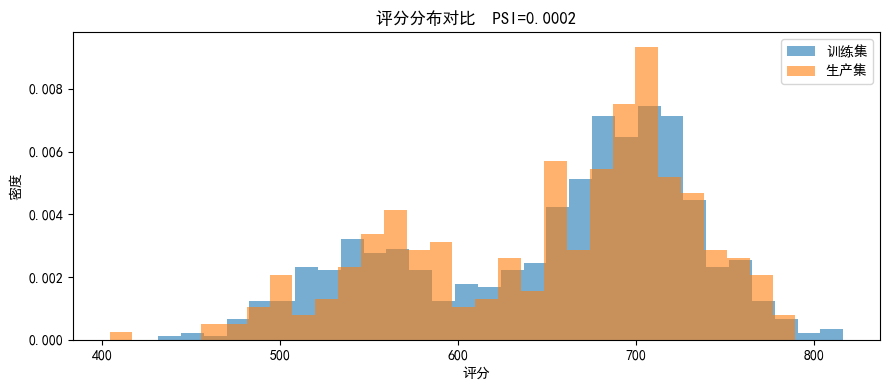

In [15]:
score_report = eda.score_drift_report(
    score_base=df_train['score'],
    score_target=df_prod['score'],
    y_base=df_train['target'],
    y_target=df_prod['target'],
    n_bins=10,
)

print(f'评分 PSI: {score_report["PSI"]}  偏移等级: {score_report["偏移等级"]}')
print('\n分布统计对比:')
display(score_report['分布统计'])

if '模型性能' in score_report:
    perf = score_report['模型性能']
    print(f'\n模型性能变化:')
    print(f'  KS:  基准={perf["基准KS"]}  目标={perf["目标KS"]}  变化={perf["KS变化"]}')
    print(f'  AUC: 基准={perf["基准AUC"]}  目标={perf["目标AUC"]}  变化={perf["AUC变化"]}')

# 可视化评分分布对比
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_train['score'].dropna(), bins=30, alpha=0.6, label='训练集', density=True)
ax.hist(df_prod['score'].dropna(),  bins=30, alpha=0.6, label='生产集', density=True)
ax.set_xlabel('评分')
ax.set_ylabel('密度')
ax.set_title(f'评分分布对比  PSI={score_report["PSI"]}')
ax.legend()
plt.tight_layout(); plt.show()

---
## 总结

| 函数 | 关键输出 |
|------|----------|
| `population_profile` | 各特征均值/分位数/缺失率/坏率，支持分组 |
| `population_shift_analysis` | PSI + 均值变化 + 偏移等级 + 建议 |
| `segment_drift_analysis` | 客群×时间 PSI 三维长表，可转 pivot 热力图 |
| `feature_cross_segment_effectiveness` | 特征在各客群的 IV/KS/AUC 宽表 |
| `approval_badrate_tradeoff` | 100点权衡曲线，辅助阈值决策 |
| `score_strategy_simulation` | 多阈值仿真：通过量/坏率/金额/拦截率 |
| `vintage_performance_summary` | Vintage 宽表，每列为 MOBx 累计坏率 |
| `roll_rate_matrix` | DPD 迁移概率矩阵 |
| `label_leakage_check` | IV/AUC 双指标告警泄露特征 |
| `multi_label_correlation` | 多标签皮尔逊/斯皮尔曼相关矩阵 |
| `feature_drift_report` | 批量特征 PSI + 均值 + 缺失率偏移 |
| `score_drift_report` | 评分 PSI + 分布统计 + 模型性能变化 |